# Visualize 3D NIfTI Volumes
This notebook provides a tool to visualize 3D NIfTI volumes from the `nifiti_outputs` directory. It displays axial, sagittal, and coronal slices and includes an interactive slider for exploration.

In [2]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os
from ipywidgets import interact, IntSlider

# Define the path to your NIfTI file
nifti_path = r'c:\Users\maila\Desktop\RSNA_Major\rsna2025_main\nifiti_outputs\701.nii.gz'

if not os.path.exists(nifti_path):
    print(f"File not found: {nifti_path}")
else:
    # Load the NIfTI image
    img = nib.load(nifti_path)
    data = img.get_fdata()
    header = img.header

    print(f"Volume Shape: {data.shape}")
    print(f"Voxel Spacing (mm): {header.get_zooms()}")
    print(f"Data Range: [{np.min(data)}, {np.max(data)}]")

Volume Shape: (512, 512, 276)
Voxel Spacing (mm): (0.43945312, 0.43945312, 0.40000916)
Data Range: [-1024.0, 3029.0]


## Multi-planar Visualization
The following function displays the central slice from each plane.

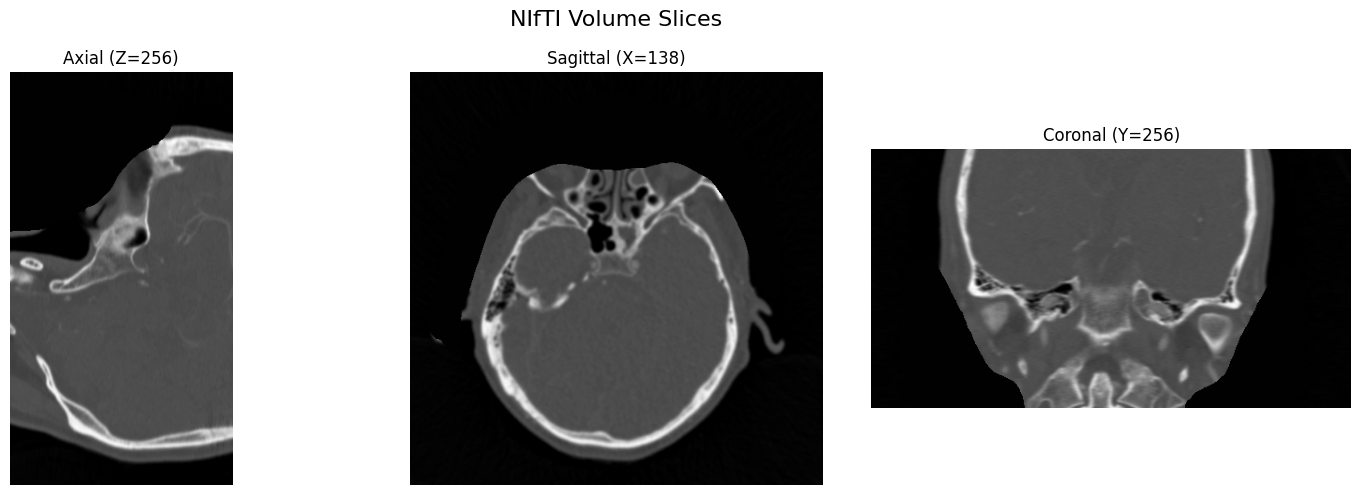

In [3]:
def show_slices(data, title="NIfTI Volume Slices"):
    """Displays the middle slice in Axial, Sagittal, and Coronal views."""
    mid_z, mid_y, mid_x = [s // 2 for s in data.shape]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=16)

    # Axial
    axes[0].imshow(data[mid_z, :, :], cmap='gray', origin='lower')
    axes[0].set_title(f'Axial (Z={mid_z})')
    axes[0].axis('off')

    # Sagittal
    axes[1].imshow(data[:, :, mid_x].T, cmap='gray', origin='lower')
    axes[1].set_title(f'Sagittal (X={mid_x})')
    axes[1].axis('off')

    # Coronal
    axes[2].imshow(data[:, mid_y, :].T, cmap='gray', origin='lower')
    axes[2].set_title(f'Coronal (Y={mid_y})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

show_slices(data)

## Interactive Slicer
Use the slider below to scroll through the Axial slices.

## 3D Volume Visualization
Interactive 3D rendering of the entire volume. You can rotate, zoom, and pan the volume.


In [4]:
def interactive_axial_viewer(z_idx):
    plt.figure(figsize=(8, 8))
    plt.imshow(data[z_idx, :, :], cmap='gray', origin='lower')
    plt.title(f'Axial View - Slice {z_idx}')
    plt.axis('off')
    plt.show()

interact(interactive_axial_viewer, 
         z_idx=IntSlider(min=0, max=data.shape[0]-1, step=1, value=data.shape[0]//2, description='Slice Z'))

interactive(children=(IntSlider(value=256, description='Slice Z', max=511), Output()), _dom_classes=('widget-i…

<function __main__.interactive_axial_viewer(z_idx)>

In [ ]:
import plotly.graph_objects as go

# Normalize data to 0-255 range for better visualization
data_normalized = ((data - np.min(data)) / (np.max(data) - np.min(data)) * 255).astype(np.uint8)

# Optional: Create a downsampled version for faster rendering (uncomment if volume is very large)
# data_viz = data_normalized[::2, ::2, ::2]  # Sample every other voxel
data_viz = data_normalized

# Create 3D volumetric rendering
fig = go.Figure(data=go.Volume(
    x=np.arange(data_viz.shape[0]),
    y=np.arange(data_viz.shape[1]),
    z=np.arange(data_viz.shape[2]),
    value=data_viz,  # Pass the 3D array directly
    isomin=30,  # Adjust to show more/less detail
    isomax=200,
    opacity=0.3,  # Transparency
    colorscale='Greys',  # Medical imaging uses grayscale
    colorbar=dict(title="Intensity")
))

fig.update_layout(
    title='3D NIfTI Volume Visualization',
    scene=dict(
        xaxis_title='X (voxels)',
        yaxis_title='Y (voxels)',
        zaxis_title='Z (voxels)',
        aspectmode='data'
    ),
    width=900,
    height=900
)

fig.show()
